# Fast.ai Unit 1 Mini Project: Ashryver Painting Classifier V1
This is the central notebook for the Fast.ai Practical Deep Learning course **Unit 1 Mini Project**, which is an image classifier designed to classify paintings based on a small subset of well-known artists. These artists are primarily taken from the Impressionistic time period. This is the **local-only, file-based** version of this model, meaning it is not yet available for use in a web environment. 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Define the dataset folder explicitly so the name is stable across cells
painting_data = Path('painting_data')
print('painting_data =', painting_data)
painting_data.mkdir(exist_ok=True, parents=True)

# Create a new folder containing any new images
painting_data_updated = Path('painting_data_updated')
# print('painting_data_updated = ', painting_data_updated)
# painting_data_updated.mkdir(exist_ok=True, parents=True)

painting_data = painting_data


## Gather data and search for images
For this project we're going to use DuckDuckGo to find some images of Impressionistic paintings. First we'll pull down some sample images of Impressionistic painters, then download larger amounts of images for training the model. 

In [2]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

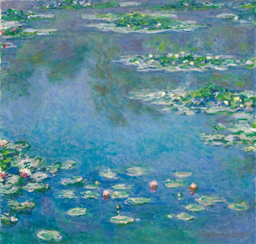

In [22]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get when searching for Monet paintings
urls = search_images('monet painting', max_images=1)
urls[0] 
 
dest = 'monet-test-1.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256) # show a preview of the image

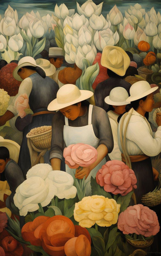

In [9]:
# Do the same thing with a variety of other Impressionistic artists before pulling down mass images to train
urls = search_images('diego rivera painting', max_images=1)
urls[0]

dest1 = 'rivera-test-1.jpg'
download_url(urls[0], dest1, show_progress=False)

im = Image.open(dest1)
im.to_thumb(256,256) # show a preview of the image

## Prepare to search and download mass images for training
For the second version of this model, **we take things a step further and incorporate some watermark-filtering techniques**. First, we exclude common stock photo sites like Getty and Alamy from all searches. Then, as a post-filter, we use a pretrained fast.ai vision learner to filter out images with watermarks and strips on them. Finally, this second version downloads **400** images per artist, into a separate folder as the first one.

In [ ]:
# full list of artists: ARTIST_NAMES = 'monet', 'renoir', 'rivera', 'degas', 'morisot', 'cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet', 'pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner', 'matisse', 'picasso', 'braque', 'mondrian', 'warhol'

def download_artist_images(artist_names: list,
                           output_dir: Path = Path('painting_data_updated'),
                           images_per_artist: int = 400,
                           URL: str = None):
    """Reusable function to download images of paintings efficiently.

    URL: optional query string or template for searches. If provided and containing
    '{artist_name}' it will be formatted per-artist, otherwise the literal string
    will be used for every artist. If omitted, a sensible default excluding
    common stock sites is used per-artist.
    """
    output_dir.mkdir(exist_ok=True, parents=True)

    for artist_name in artist_names:
        artist_dir = output_dir / artist_name
        artist_dir.mkdir(exist_ok=True, parents=True)

        # Determine query to use for this artist
        if URL is None:
            query = artist_name + " painting -site:gettyimages.com -site:alamy.com -site:123rf.com"
        else:
            try:
                query = URL.format(artist_name=artist_name)
            except Exception:
                # If formatting fails, fall back to using the URL string as-is
                query = URL

        urls = search_images(query, max_images=images_per_artist)

        download_images(artist_dir, urls=urls)
        print(f"Downloaded {len(urls)} images for {artist_name}")

# Pull down photos of the first 5 artists
artists_batch_1 = ['monet', 'renoir', 'rivera', 'degas', 'morisot']
download_artist_images(artists_batch_1)

In [ ]:
# Pull down photos of the next 5 artists
artists_batch_2 = ['cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet']
download_artist_images(artists_batch_2)

artists_batch_3 = ['pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner']
download_artist_images(artists_batch_3)

matisse = ['matisse']
download_artist_images(matisse, ' matisse the bees -site:gettyimages.com -site:alamy.com -site:123rf.com')

artists_batch_4 = ['picasso', 'braque', 'mondrian', 'warhol']
download_artist_images(artists_batch_4)

AttributeError: 'str' object has no attribute 'mkdir'

## Train the model
We will now proceed to train a **resnet34** classifier model and see how it performs on the given data. The resnet34 classifier is one of the pretrained models offered by PyTorch, and we will create the model using a traditional DataBlock architecture.

In [30]:
# Check to see if any of the images failed to download properly
failed = verify_images(get_image_files(painting_data_updated))
# verify_images returns a list (or L) of file paths that failed verification
for f in failed:
    try:
        Path(f).unlink()
    except Exception as e:
        print(f'Could not remove {f}: {e}')
print(f'Removed {len(failed)} failed images.')

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c45a1950ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c45a1950ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Removed 29 failed images.


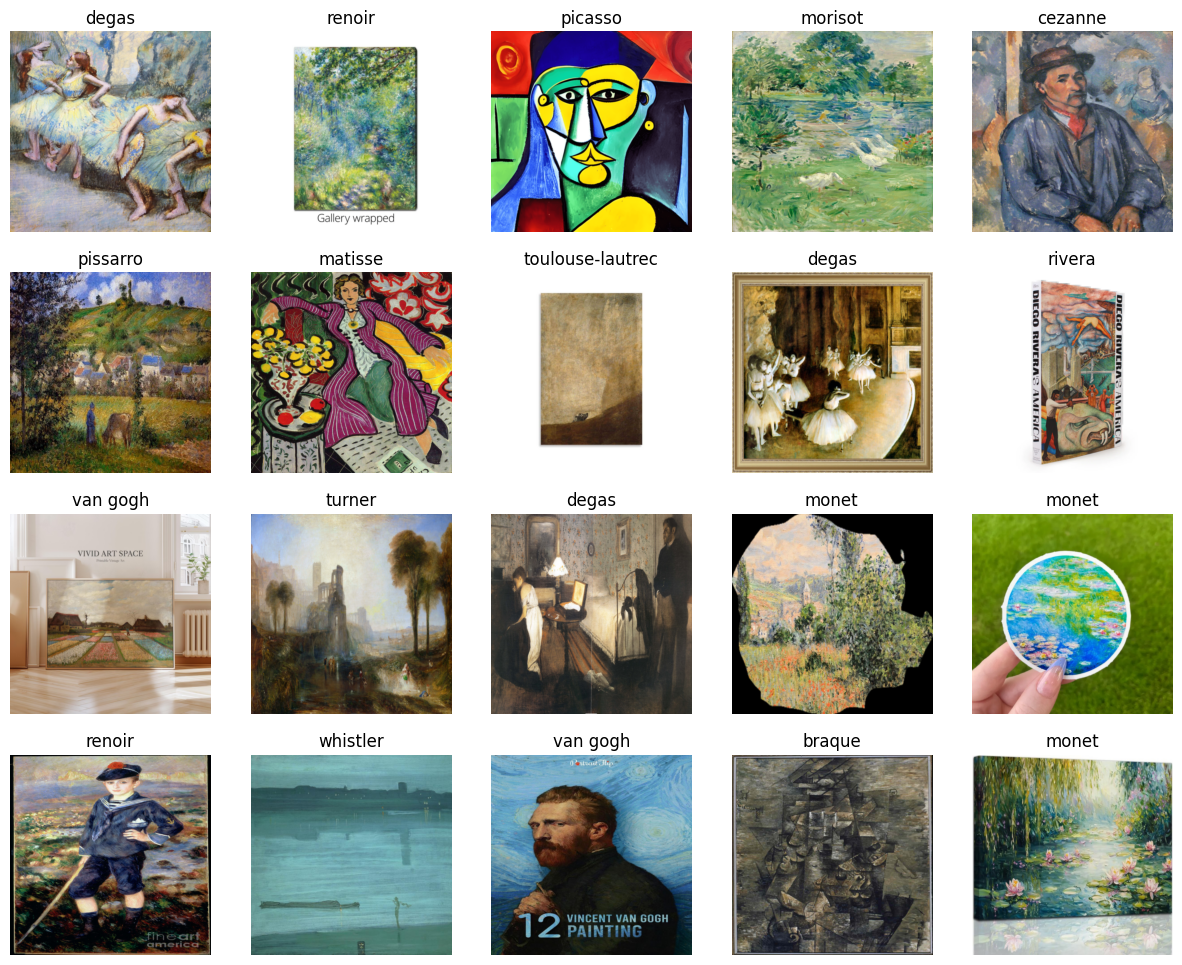

In [ ]:
# Dataset size (for reference): train items 2149, validation items 537 (2,686 total, making for a small-to-medium dataset)

# Create the Datablock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(448, method='squish')]
).dataloaders(painting_data_updated, bs=32)

dls.show_batch(max_n=20) # show a sample of 20 images that the model will be trained upon

# you may notice that very occasionally, one of the images may have Getty or Alamy watermarks on them--we'll leave
# that alone for now, but if it becomes a problem, we'll have to address that issue.

In [ ]:
# Train the resnet50 model
learn = vision_learner(dls, resnet50, metrics=error_rate)
learn.fine_tune(4) # train for 4 epochs

# resnet50 224x224 model reportedly achieved 0.89 accuracy on the validation set

epoch,train_loss,valid_loss,error_rate,time
0,2.355764,1.487227,0.400624,02:25


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

epoch,train_loss,valid_loss,error_rate,time
0,1.299391,1.100565,0.303850,03:06
1,0.902690,1.037434,0.260146,03:03
2,0.424316,0.949810,0.234131,03:02
3,0.199129,0.949014,0.235172,03:02


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

In [33]:
# Save the latest model version
learn.export('painting_classifier_resnet50_newdata_224x224.pkl')

## Test the model and make predictions
Here's the most important part of training this painting classifier: making sure it actually works. I've downloaded some randomly-chosen sample images of Impressionistic paintings so it can make predictions, including one by a modern artist, but done in the Impressionistic style.

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


This is a Warhol painting.
All Probabilities
braque: 0.00%
cassatt: 0.00%
cezanne: 0.00%
degas: 0.00%
gauguin: 0.00%
manet: 0.00%
matisse: 0.00%
mondrian: 0.00%
monet: 0.00%
morisot: 0.00%
picasso: 0.00%
pissarro: 0.00%
renoir: 0.00%
rivera: 0.00%
seurat: 0.00%
toulouse-lautrec: 0.00%
turner: 0.00%
van gogh: 0.00%
warhol: 99.99%
whistler: 0.00%


<Axes: >

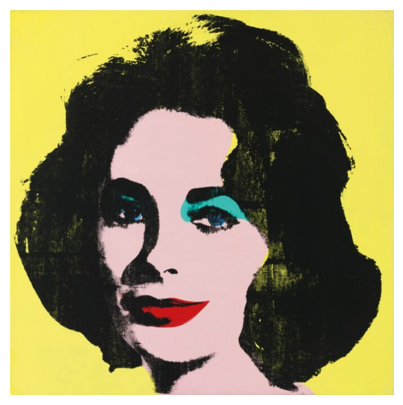

In [12]:
learn = load_learner('painting_classifier_resnet50_400perartist_224x224.pkl')

img = PILImage.create('painting-test-5.jpg')

pred_label, pred_idx, all_probs = learn.predict(img)
formatted_pred = pred_label.capitalize() # capitalize the artist's name in the prediction

print(f"This is a {formatted_pred} painting.\n============================\nAll Probabilities")
for class_name, probability in zip(learn.dls.vocab, all_probs):
    prob_val = probability * 100 # format to a percentage
    if class_name == pred_label:
            print(f"\033[1;32m{class_name}: {prob_val:.2f}%\033[0m") # output the predicted label as bold and green
    else:
        print(f"{class_name}: {prob_val:.2f}%")
show_image(img)

# Notice that for 'painting-test-3.jpeg', which is a painting by modern artist Karen Hale, it decides that it's a Turner/Monet painting. Interesting to see what the model chooses when given unfamiliar, but still Impressionistic, paintings.
# Additional note, right now it's giving an incorrect prediction (mondrian/whistler) for Henri Matisse's The Bees. Might have to look into this.

## Get the full classification report on the model
We use a custom function here, evaluate_model, to take care of any possible issues with validation datasets being empty, and output a complete classification report.

**As of version 3, trained on 6/30/2026, the model is now achieving 0.89 accuracy, confirmed on multiple validation runs and real-time image tests**. However, the model is still making incorrect predictions on certain Matisse paintings, specifically The Bees, which is one of Matisse's very strange ones and diverges from his typical style.**This accuracy was achieved after switching to the deeper resnet50 architecture.**

In [ ]:
# Filename of 0.89-accuracy model (latest revision): painting_classifier_resnet50_400perartist_224x224.pkl
learn = load_learner('painting_classifier_resnet50_400perartist_224x224.pkl')

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(224, method='squish')] # 224x224 image size for capturing more fine details
).dataloaders(painting_data, bs=32)

learn.dls = dls

print("train items:", len(learn.dls.train.dataset))
print("valid items:", len(learn.dls.valid.dataset))
print("vocab:", learn.dls.vocab)

def evaluate_model(learn, test_dl=None):
    """Get detailed metrics on how the classification model is performing"""
    if test_dl is None:
        test_dl = learn.dls.valid
    elif isinstance(test_dl, DataLoaders):
        test_dl = test_dl.valid

    if len(test_dl.dataset) == 0:
        raise ValueError("test_dl is empty; cannot evaluate model performance")

    preds, targs = learn.get_preds(dl=test_dl)
    if preds is None:
        raise RuntimeError("learn.get_preds() returned None. Ensure the learner and DataLoader are valid.")

    pred_classes = preds.argmax(dim=1)

    from sklearn.metrics import classification_report, confusion_matrix

    print("=== Classification Report ===")
    print(classification_report(targs, pred_classes, target_names=learn.dls.vocab))

    return confusion_matrix(targs, pred_classes)

evaluate_model(learn)

train items: 2149
valid items: 537
vocab: ['braque', 'cassatt', 'cezanne', 'degas', 'gauguin', 'manet', 'matisse', 'mondrian', 'monet', 'morisot', 'picasso', 'pissarro', 'renoir', 'rivera', 'seurat', 'toulouse-lautrec', 'turner', 'van gogh', 'warhol', 'whistler']


=== Classification Report ===
                  precision    recall  f1-score   support

          braque       0.96      0.89      0.93        28
         cassatt       0.95      0.69      0.80        29
         cezanne       0.84      0.87      0.86        31
           degas       1.00      1.00      1.00        31
         gauguin       1.00      0.82      0.90        28
           manet       0.90      0.93      0.91        28
         matisse       1.00      0.76      0.86        29
        mondrian       0.83      1.00      0.91        20
           monet       0.92      0.88      0.90        25
         morisot       0.93      0.88      0.90        32
         picasso       0.64      0.94      0.76        17
        pissarro       0.82      1.00      0.90        27
          renoir       0.85      0.79      0.81        28
          rivera       0.79      0.85      0.82        27
          seurat       1.00      0.96      0.98        28
toulouse-lautrec       0.88      0.82    

array([[25,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  0,
         0,  0,  1,  0],
       [ 0, 20,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  2,  2,  0,  0,
         0,  0,  0,  4],
       [ 0,  0, 27,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
         1,  1,  0,  0],
       [ 0,  0,  0, 31,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  2,  0, 23,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,
         0,  1,  0,  0],
       [ 0,  0,  0,  0,  0, 26,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
         1,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0, 22,  1,  0,  0,  4,  0,  0,  0,  0,  0,
         0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 22,  0,  0,  2,  0,  0,  0,  0,
         1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  2,  0,  0,  0, 28,  0,  0,  0,  0,  0,  1,
         1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0